# Thesis Evaluation Notebook for RAG-YHCT

This notebook evaluates retrieval, gate behavior, and answer quality of the current serving pipeline:

**Hybrid RRF -> Answerability Gate -> Focused Context -> Local LLM Answer + Citations**

It is designed for thesis/report screenshots and can run cell-by-cell.

## Part 1 - Setup

In [1]:
import json
from pathlib import Path
import statistics
import textwrap

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [2]:
# Editable configuration (project-relative paths)
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() or (p / "README.md").exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd())

RETRIEVAL_ABLATION_PATH = Path("data/reports/retrieval_ablation_qset_100_seed42.json")
H1_REPORT_PATH = Path("data/reports/h1_full_report.json")
RETRIEVAL_DEBUG_DIR = Path("data/reports/retrieval_debug")
TABLE_OUTPUT_DIR = Path("data/reports/tables")

print(f"Project root: {PROJECT_ROOT}")
print(f"Retrieval ablation: {(PROJECT_ROOT / RETRIEVAL_ABLATION_PATH)}")
print(f"H1 report: {(PROJECT_ROOT / H1_REPORT_PATH)}")
print(f"Retrieval debug dir: {(PROJECT_ROOT / RETRIEVAL_DEBUG_DIR)}")
print(f"Table output dir: {(PROJECT_ROOT / TABLE_OUTPUT_DIR)}")

Project root: /home/chplay2020/src/vn-yhct-rag/rag-yhct
Retrieval ablation: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/retrieval_ablation_qset_100_seed42.json
H1 report: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/h1_full_report.json
Retrieval debug dir: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/retrieval_debug
Table output dir: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/tables


## Part 2 - Load Data

In [3]:
def read_json_safe(path: Path, warnings: list[str], label: str = ""):
    if not path.exists():
        warnings.append(f"WARNING: missing file -> {path}")
        return None
    try:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as exc:
        prefix = f"{label}: " if label else ""
        warnings.append(f"WARNING: failed to parse {prefix}{path} ({exc})")
        return None


def list_json_files_safe(folder: Path, pattern: str, warnings: list[str]) -> list[Path]:
    if not folder.exists():
        warnings.append(f"WARNING: missing folder -> {folder}")
        return []
    return sorted(folder.glob(pattern))


def nested_get(obj, *keys, default=None):
    cur = obj
    for key in keys:
        if isinstance(cur, dict) and key in cur:
            cur = cur[key]
        else:
            return default
    return cur


load_warnings: list[str] = []

retrieval_ablation = read_json_safe(PROJECT_ROOT / RETRIEVAL_ABLATION_PATH, load_warnings, "retrieval_ablation")
h1_report = read_json_safe(PROJECT_ROOT / H1_REPORT_PATH, load_warnings, "h1_report")

debug_base_files = list_json_files_safe(PROJECT_ROOT / RETRIEVAL_DEBUG_DIR, "*.json", load_warnings)
debug_gate_files = list_json_files_safe(PROJECT_ROOT / RETRIEVAL_DEBUG_DIR, "*_gate.json", load_warnings)
debug_answer_files = list_json_files_safe(PROJECT_ROOT / RETRIEVAL_DEBUG_DIR, "*_answer.json", load_warnings)

print("Load summary:")
print(f"- retrieval_ablation loaded: {retrieval_ablation is not None}")
print(f"- h1_report loaded: {h1_report is not None}")
print(f"- retrieval_debug JSON files: {len(debug_base_files)}")
print(f"- gate files: {len(debug_gate_files)}")
print(f"- answer files: {len(debug_answer_files)}")

if load_warnings:
    print("\nWarnings:")
    for w in load_warnings:
        print(w)
else:
    print("\nNo loading warnings.")

Load summary:
- retrieval_ablation loaded: True
- h1_report loaded: True
- retrieval_debug JSON files: 35
- gate files: 14
- answer files: 5

No loading warnings.


## Part 3 - Retrieval Ablation Summary

In [4]:
metric_order = ["hit@1", "hit@3", "hit@5", "hit@10", "mrr"]
entity_order = ["chunk_id", "parent_id", "source_id"]


def normalize_metric_key(k: str) -> str:
    return str(k).strip().lower().replace(" ", "")


def get_metric_block(mode_metrics: dict, metric_name: str):
    wanted = normalize_metric_key(metric_name)
    if not isinstance(mode_metrics, dict):
        return {}
    for k, v in mode_metrics.items():
        if normalize_metric_key(k) == wanted and isinstance(v, dict):
            return v
    return {}


rows = []
metrics_block = nested_get(retrieval_ablation or {}, "metrics", default={})

if isinstance(metrics_block, dict) and metrics_block:
    for mode, mode_metrics in metrics_block.items():
        row = {"mode": mode}
        for metric_name in metric_order:
            metric_block = get_metric_block(mode_metrics, metric_name)
            for entity in entity_order:
                col = f"{metric_name}_{entity}"
                value = metric_block.get(entity) if isinstance(metric_block, dict) else None
                row[col] = value
        rows.append(row)
else:
    print("WARNING: retrieval metrics are not available.")

df_retrieval_summary = pd.DataFrame(rows)

if not df_retrieval_summary.empty:
    metric_cols = [c for c in df_retrieval_summary.columns if c != "mode"]
    df_retrieval_summary[metric_cols] = df_retrieval_summary[metric_cols].apply(pd.to_numeric, errors="coerce")
    df_retrieval_summary = df_retrieval_summary.sort_values(by="mode").reset_index(drop=True)

    display(Markdown("### Compact retrieval summary"))
    display(df_retrieval_summary)

    def highlight_best(s: pd.Series):
        if s.name == "mode":
            return ["" for _ in s]
        numeric = pd.to_numeric(s, errors="coerce")
        if numeric.notna().sum() == 0:
            return ["" for _ in s]
        best = numeric.max()
        return ["background-color: #d7f5d8; font-weight: bold" if pd.notna(v) and v == best else "" for v in numeric]

    display(Markdown("### Best mode highlighted for each metric"))
    display(df_retrieval_summary.style.apply(highlight_best, axis=0).format(precision=4))
else:
    display(Markdown("**No retrieval ablation data available.**"))

### Compact retrieval summary

,mode,hit@1_chunk_id,hit@1_parent_id,hit@1_source_id,hit@3_chunk_id,hit@3_parent_id,hit@3_source_id,hit@5_chunk_id,hit@5_parent_id,hit@5_source_id,hit@10_chunk_id,hit@10_parent_id,hit@10_source_id,mrr_chunk_id,mrr_parent_id,mrr_source_id
0,bm25,0.35,0.38,0.44,0.58,0.59,0.69,0.61,0.63,0.76,0.64,0.66,0.79,0.4646,0.4876,0.5726
1,hybrid_rrf,0.39,0.44,0.52,0.55,0.60,0.77,0.62,0.65,0.86,0.72,0.75,0.96,0.4902,0.5387,0.6710
2,vector,0.34,0.39,0.59,0.46,0.54,0.84,0.53,0.61,0.90,0.55,0.64,0.95,0.4132,0.4783,0.7252


### Best mode highlighted for each metric

,mode,hit@1_chunk_id,hit@1_parent_id,hit@1_source_id,hit@3_chunk_id,hit@3_parent_id,hit@3_source_id,hit@5_chunk_id,hit@5_parent_id,hit@5_source_id,hit@10_chunk_id,hit@10_parent_id,hit@10_source_id,mrr_chunk_id,mrr_parent_id,mrr_source_id
0,bm25,0.3500,0.3800,0.4400,0.5800,0.5900,0.6900,0.6100,0.6300,0.7600,0.6400,0.6600,0.7900,0.4646,0.4876,0.5726
1,hybrid_rrf,0.3900,0.4400,0.5200,0.5500,0.6000,0.7700,0.6200,0.6500,0.8600,0.7200,0.7500,0.9600,0.4902,0.5387,0.6710
2,vector,0.3400,0.3900,0.5900,0.4600,0.5400,0.8400,0.5300,0.6100,0.9000,0.5500,0.6400,0.9500,0.4132,0.4783,0.7252


## Part 4 - Retrieval Charts

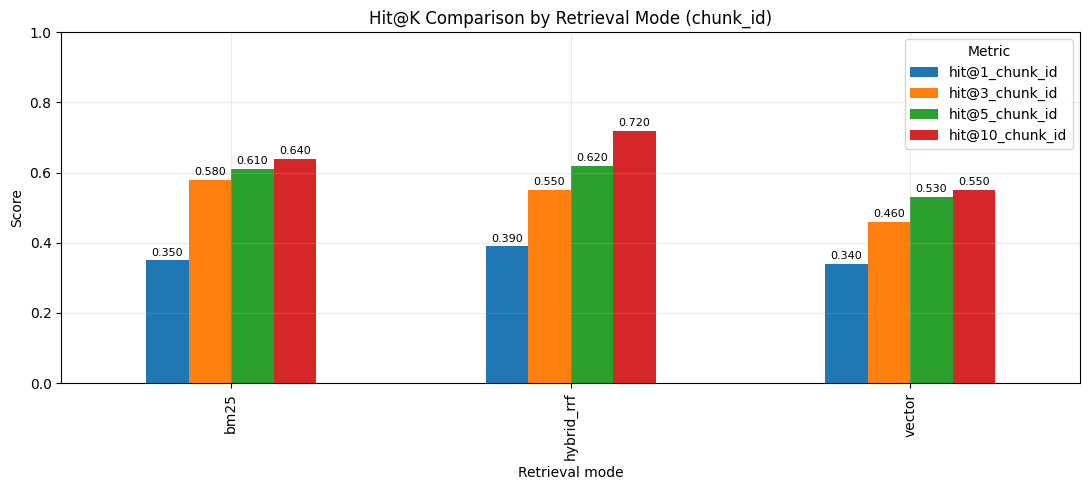

In [5]:
if df_retrieval_summary.empty:
    print("No retrieval summary available for charting.")
else:
    # Chart 1: Hit@1/3/5/10 across modes (chunk_id)
    hit_cols = ["hit@1_chunk_id", "hit@3_chunk_id", "hit@5_chunk_id", "hit@10_chunk_id"]
    hit_plot_df = df_retrieval_summary[["mode", *[c for c in hit_cols if c in df_retrieval_summary.columns]]].copy()

    long_hit = hit_plot_df.melt(id_vars="mode", var_name="metric", value_name="value").dropna()
    if long_hit.empty:
        print("No Hit@K chunk_id values available.")
    else:
        pivot_hit = long_hit.pivot(index="mode", columns="metric", values="value")
        desired = [m for m in hit_cols if m in pivot_hit.columns]
        pivot_hit = pivot_hit.reindex(columns=desired)

        ax = pivot_hit.plot(kind="bar", figsize=(11, 5))
        ax.set_title("Hit@K Comparison by Retrieval Mode (chunk_id)")
        ax.set_xlabel("Retrieval mode")
        ax.set_ylabel("Score")
        ax.set_ylim(0, max(1.0, float(long_hit["value"].max()) * 1.15))
        ax.legend(title="Metric")

        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)

        plt.tight_layout()
        plt.show()

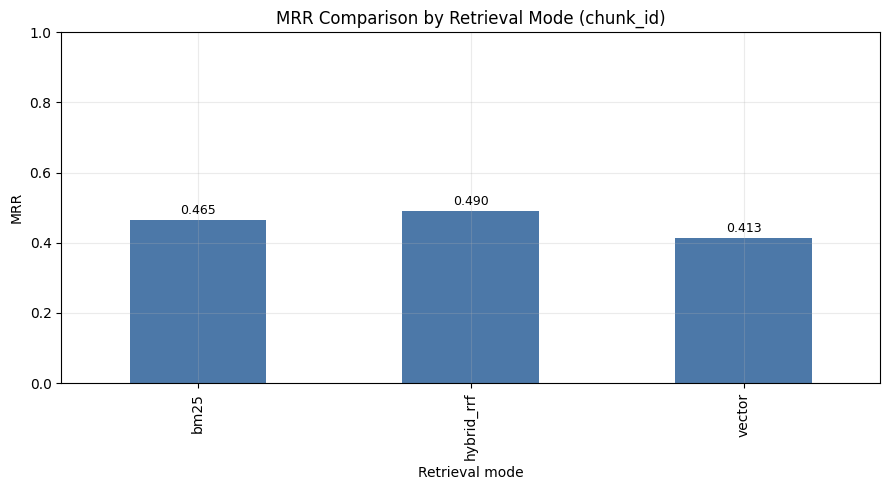

In [6]:
if df_retrieval_summary.empty:
    print("No retrieval summary available for charting.")
else:
    # Chart 2: MRR comparison (chunk_id)
    mrr_cols = [c for c in df_retrieval_summary.columns if c.endswith("mrr_chunk_id") or c == "mrr_chunk_id"]
    mrr_col = "mrr_chunk_id" if "mrr_chunk_id" in df_retrieval_summary.columns else (mrr_cols[0] if mrr_cols else None)

    if not mrr_col:
        print("No MRR chunk_id column found.")
    else:
        mrr_plot_df = df_retrieval_summary[["mode", mrr_col]].dropna().copy()
        ax = mrr_plot_df.plot(kind="bar", x="mode", y=mrr_col, legend=False, figsize=(9, 5), color="#4c78a8")
        ax.set_title("MRR Comparison by Retrieval Mode (chunk_id)")
        ax.set_xlabel("Retrieval mode")
        ax.set_ylabel("MRR")
        ax.set_ylim(0, max(1.0, float(mrr_plot_df[mrr_col].max()) * 1.2 if not mrr_plot_df.empty else 1.0))

        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=2, fontsize=9)

        plt.tight_layout()
        plt.show()

## Part 5 - Load H1 Report

In [7]:
def len_or_none(v):
    if isinstance(v, list):
        return len(v)
    if isinstance(v, dict):
        return len(v)
    return None

h1_summary = {}
if h1_report is None:
    print("H1 report missing.")
    df_h1_summary = pd.DataFrame(columns=["metric", "value"])
else:
    h1_summary = {
        "raw_passages": nested_get(h1_report, "raw", "count"),
        "clean_passages": nested_get(h1_report, "clean", "count"),
        "chunks": nested_get(h1_report, "chunks", "count"),
        "noise_count": nested_get(h1_report, "chunks", "noise_count"),
        "qdrant_count": nested_get(h1_report, "qdrant", "point_count", default=nested_get(h1_report, "qdrant", "points_count")),
        "error_chunks": nested_get(h1_report, "error_counts", "fffd_chunks", default=0)
                        + nested_get(h1_report, "error_counts", "letter_nl_letter_chunks", default=0)
                        + nested_get(h1_report, "error_counts", "sci_name_split_chunks", default=0),
        "parent_count": nested_get(h1_report, "parents", "count", default=nested_get(h1_report, "chunks", "unique_parent_ids")),
    }

    print("H1 key values:")
    print(f"- Raw passages: {h1_summary['raw_passages']}")
    print(f"- Clean passages: {h1_summary['clean_passages']}")
    print(f"- Chunks: {h1_summary['chunks']}")
    print(f"- Noise count: {h1_summary['noise_count']}")
    print(f"- Qdrant count: {h1_summary['qdrant_count']}")
    print(f"- Error chunks: {h1_summary['error_chunks']}")
    print(f"- Parent count: {h1_summary['parent_count']}")

    df_h1_summary = pd.DataFrame({
        "metric": [
            "Raw passages",
            "Clean passages",
            "Chunks",
            "Noise count",
            "Qdrant count",
            "Error chunks",
            "Parent count",
        ],
        "value": [
            h1_summary["raw_passages"],
            h1_summary["clean_passages"],
            h1_summary["chunks"],
            h1_summary["noise_count"],
            h1_summary["qdrant_count"],
            h1_summary["error_chunks"],
            h1_summary["parent_count"],
        ]
    })

display(Markdown("### H1 compact summary table"))
display(df_h1_summary)

H1 key values:
- Raw passages: 21029
- Clean passages: 21029
- Chunks: 24620
- Noise count: 59
- Qdrant count: 24553
- Error chunks: 4
- Parent count: None


### H1 compact summary table

,metric,value
0,Raw passages,21029.0
1,Clean passages,21029.0
2,Chunks,24620.0
3,Noise count,59.0
4,Qdrant count,24553.0
5,Error chunks,4.0
6,Parent count,NaN


## Part 6 - Gate and Answer Analysis

In [8]:
def stem_without_suffix(path: Path, suffix: str) -> str:
    name = path.name
    return name[:-len(suffix)] if name.endswith(suffix) else path.stem


def first_non_none(*vals):
    for v in vals:
        if v is not None:
            return v
    return None


gate_map = {stem_without_suffix(p, "_gate.json"): p for p in debug_gate_files}
answer_map = {stem_without_suffix(p, "_answer.json"): p for p in debug_answer_files}

base_candidates = [
    p for p in debug_base_files
    if not p.name.endswith("_gate.json") and not p.name.endswith("_answer.json")
]
base_map = {p.stem: p for p in base_candidates}

all_ids = sorted(set(gate_map) | set(answer_map) | set(base_map))

analysis_warnings: list[str] = []
rows = []

for run_id in all_ids:
    gate_obj = read_json_safe(gate_map[run_id], analysis_warnings, f"gate:{run_id}") if run_id in gate_map else None
    answer_obj = read_json_safe(answer_map[run_id], analysis_warnings, f"answer:{run_id}") if run_id in answer_map else None
    base_obj = read_json_safe(base_map[run_id], analysis_warnings, f"base:{run_id}") if run_id in base_map else None

    query = first_non_none(
        nested_get(answer_obj or {}, "query"),
        nested_get(gate_obj or {}, "query"),
        nested_get(base_obj or {}, "query"),
    )

    gate_pass = first_non_none(
        nested_get(gate_obj or {}, "gate_pass"),
        nested_get(answer_obj or {}, "gate_result", "pass"),
    )

    gate_reason = first_non_none(
        nested_get(gate_obj or {}, "reason"),
        nested_get(answer_obj or {}, "gate_result", "reason"),
    )

    predicted_citation_count = first_non_none(
        nested_get(gate_obj or {}, "predicted_citation_count"),
        nested_get(answer_obj or {}, "gate_result", "predicted_citation_count"),
    )

    final_context_token_count = first_non_none(
        nested_get(answer_obj or {}, "context", "debug", "final_context_token_count"),
        nested_get(answer_obj or {}, "context", "debug", "final_context_tokens"),
        nested_get(gate_obj or {}, "context", "debug", "final_context_token_count"),
        nested_get(gate_obj or {}, "context", "debug", "final_context_tokens"),
    )

    answer_text = first_non_none(
        nested_get(answer_obj or {}, "answer", "answer"),
        nested_get(answer_obj or {}, "answer"),
    )
    answer_generated = bool(isinstance(answer_text, str) and answer_text.strip())

    abstained = False
    if gate_pass is False and not answer_generated:
        abstained = True

    evidence_list = nested_get(answer_obj or {}, "answer", "evidence", default=[])
    if not isinstance(evidence_list, list):
        evidence_list = []

    evidence_count = first_non_none(
        len(evidence_list) if evidence_list else None,
        nested_get(gate_obj or {}, "gate_features", "evidence_count"),
        nested_get(answer_obj or {}, "gate_result", "gate_features", "evidence_count"),
    )

    answer_length = len(answer_text) if isinstance(answer_text, str) else 0

    selected_parent_ids = first_non_none(
        nested_get(answer_obj or {}, "context", "debug", "selected_parent_ids"),
        nested_get(gate_obj or {}, "context", "debug", "selected_parent_ids"),
        [],
    )

    if not isinstance(selected_parent_ids, list):
        selected_parent_ids = []

    limits = nested_get(answer_obj or {}, "answer", "limits")
    safety_note = nested_get(answer_obj or {}, "answer", "safety_note")

    evidence_snippets = []
    for ev in evidence_list[:3]:
        if isinstance(ev, dict):
            snip = ev.get("snippet") or ev.get("text")
            if isinstance(snip, str) and snip.strip():
                evidence_snippets.append(textwrap.shorten(snip.replace("\n", " "), width=240, placeholder="..."))

    if not evidence_snippets:
        fallback_ev = first_non_none(
            nested_get(answer_obj or {}, "selected_evidence", default=[]),
            nested_get(gate_obj or {}, "selected_evidence", default=[]),
            [],
        )
        if isinstance(fallback_ev, list):
            for ev in fallback_ev[:3]:
                if isinstance(ev, dict):
                    snip = ev.get("text") or ev.get("snippet")
                    if isinstance(snip, str) and snip.strip():
                        evidence_snippets.append(textwrap.shorten(snip.replace("\n", " "), width=240, placeholder="..."))

    rows.append({
        "run_id": run_id,
        "query": query,
        "gate_pass": gate_pass,
        "predicted_citation_count": predicted_citation_count,
        "gate_reason": gate_reason,
        "final_context_token_count": final_context_token_count,
        "answer_generated": answer_generated,
        "abstained": abstained,
        "answer_length": answer_length,
        "evidence_count": evidence_count,
        "answer": answer_text,
        "limits": limits,
        "safety_note": safety_note,
        "top_evidence_snippets": evidence_snippets,
        "selected_parent_ids": selected_parent_ids,
    })

df_gate_summary = pd.DataFrame(rows)

if not df_gate_summary.empty:
    for c in ["predicted_citation_count", "final_context_token_count", "answer_length", "evidence_count"]:
        if c in df_gate_summary.columns:
            df_gate_summary[c] = pd.to_numeric(df_gate_summary[c], errors="coerce")

    display(Markdown("### Gate/answer summary table"))
    display(df_gate_summary[[
        "run_id", "query", "gate_pass", "predicted_citation_count", "gate_reason",
        "final_context_token_count", "answer_generated", "abstained", "answer_length", "evidence_count"
    ]])
else:
    display(Markdown("**No gate/answer debug data found.**"))

if analysis_warnings:
    print("\nAnalysis warnings:")
    for w in analysis_warnings:
        print(w)

### Gate/answer summary table

,run_id,query,gate_pass,predicted_citation_count,gate_reason,final_context_token_count,answer_generated,abstained,answer_length,evidence_count
0,bm25_263aee33,tác dụng của cây ngải cứu,None,NaN,None,NaN,False,False,0,NaN
1,hybrid_rrf_09b8db9d,Cây Mã Đề,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,NaN,False,False,0,5.0
2,hybrid_rrf_263aee33,tác dụng của cây ngải cứu,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,1669.0,True,False,538,3.0
3,hybrid_rrf_3fe8052c,cách chữa trẻ em ho do cảm lạnh bằng cây thuốc-dược liệu là gì,False,1.0,Insufficient strong evidence passages.,NaN,False,True,0,1.0
4,hybrid_rrf_4143dfa4,tác dụng của cây sả,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,3500.0,True,False,269,4.0
5,hybrid_rrf_492bba9f,tác dụng của cây xả,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,NaN,False,False,0,5.0
6,hybrid_rrf_4a49a95e,"Dược liệu chữa ho, hen là gì",False,1.0,Insufficient strong evidence passages.,NaN,False,True,0,1.0
7,hybrid_rrf_760bd221,cây chi sả có tên khác là gì,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,NaN,False,False,0,5.0
8,hybrid_rrf_7e7ba53b,Tên khoa học của cây câu kỷ là gì,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,NaN,False,False,0,5.0
9,hybrid_rrf_82132096,cách chữa trẻ em ho do cảm lạnh là gì,False,2.0,Evidence lacks concentrated agreement (same parent/source).,NaN,False,True,0,2.0


In [9]:
if df_gate_summary.empty:
    print("No gate summary stats available.")
    gate_stats = {}
else:
    n_total = len(df_gate_summary)
    gate_pass_count = int((df_gate_summary["gate_pass"] == True).sum())
    gate_fail_count = int((df_gate_summary["gate_pass"] == False).sum())
    abstained_count = int((df_gate_summary["abstained"] == True).sum())

    evidence_values = [v for v in df_gate_summary["evidence_count"].dropna().tolist() if pd.notna(v)]
    context_values = [v for v in df_gate_summary["final_context_token_count"].dropna().tolist() if pd.notna(v)]

    avg_evidence_count = statistics.fmean(evidence_values) if evidence_values else None
    avg_context_tokens = statistics.fmean(context_values) if context_values else None

    answer_generated_count = int((df_gate_summary["answer_generated"] == True).sum())
    answer_generation_rate = answer_generated_count / n_total if n_total else None

    gate_fail_df = df_gate_summary[df_gate_summary["gate_pass"] == False]
    gate_fail_but_answer_generated_count = int((gate_fail_df["answer_generated"] == True).sum()) if not gate_fail_df.empty else 0
    gate_fail_but_answer_generated_rate = (
        gate_fail_but_answer_generated_count / len(gate_fail_df)
        if len(gate_fail_df) > 0
        else 0.0
    )

    gate_stats = {
        "total_queries": n_total,
        "gate_pass": gate_pass_count,
        "gate_fail": gate_fail_count,
        "abstained_queries": abstained_count,
        "avg_evidence_count": avg_evidence_count,
        "avg_context_tokens": avg_context_tokens,
        "answer_generation_rate": answer_generation_rate,
        "gate_fail_but_answer_generated_rate": gate_fail_but_answer_generated_rate,
    }

    stats_df = pd.DataFrame({"metric": list(gate_stats.keys()), "value": list(gate_stats.values())})
    display(Markdown("### Gate and answer statistics"))
    display(stats_df)

### Gate and answer statistics

,metric,value
0,total_queries,16.000000
1,gate_pass,9.000000
2,gate_fail,5.000000
3,abstained_queries,4.000000
4,avg_evidence_count,3.428571
5,avg_context_tokens,2979.400000
6,answer_generation_rate,0.312500
7,gate_fail_but_answer_generated_rate,0.200000


## Part 7 - Case Study Section

In [10]:
def choose_case(df: pd.DataFrame, condition, fallback_used: set[str]):
    if df.empty:
        return None
    subset = df[condition].copy()
    if not subset.empty:
        for _, r in subset.iterrows():
            if r["run_id"] not in fallback_used:
                fallback_used.add(r["run_id"])
                return r
    for _, r in df.iterrows():
        if r["run_id"] not in fallback_used:
            fallback_used.add(r["run_id"])
            return r
    return df.iloc[0]


case_rows = []
used_ids: set[str] = set()

if df_gate_summary.empty:
    df_case_studies = pd.DataFrame(columns=[
        "case_group", "run_id", "query", "gate_result", "answer", "limits",
        "safety_note", "top_evidence_snippets", "selected_parent_ids"
    ])
    print("No case studies available from debug files.")
else:
    # 1) Good answered query
    good = choose_case(
        df_gate_summary,
        (df_gate_summary["gate_pass"] == True) & (df_gate_summary["answer_generated"] == True) & (df_gate_summary["evidence_count"].fillna(0) >= 2),
        used_ids
    )

    # 2) Gate fail or abstain query
    gate_fail = choose_case(
        df_gate_summary,
        (df_gate_summary["gate_pass"] == False) | (df_gate_summary["abstained"] == True),
        used_ids
    )

    # 3) Potentially noisy or imperfect context
    noisy = choose_case(
        df_gate_summary,
        (df_gate_summary["evidence_count"].fillna(0) <= 1)
        | (df_gate_summary["final_context_token_count"].fillna(0) < 1200)
        | (df_gate_summary["gate_reason"].fillna("").str.lower().str.contains("insufficient|lack|mismatch|fail")),
        used_ids
    )

    selected = [
        ("Good answered query", good),
        ("Gate fail / abstain query", gate_fail),
        ("Potentially noisy or imperfect context", noisy),
    ]

    for case_group, row in selected:
        if row is None:
            continue
        case_rows.append({
            "case_group": case_group,
            "run_id": row.get("run_id"),
            "query": row.get("query"),
            "gate_result": row.get("gate_pass"),
            "answer": row.get("answer"),
            "limits": row.get("limits"),
            "safety_note": row.get("safety_note"),
            "top_evidence_snippets": row.get("top_evidence_snippets"),
            "selected_parent_ids": row.get("selected_parent_ids"),
        })

    df_case_studies = pd.DataFrame(case_rows)

display(Markdown("### Case study table"))
display(df_case_studies)

### Case study table

,case_group,run_id,query,gate_result,answer,limits,safety_note,top_evidence_snippets,selected_parent_ids
0,Good answered query,hybrid_rrf_263aee33,tác dụng của cây ngải cứu,True,"Cây ngải cứu (Artemisia vulgaris L. [E1] ) thuộc họ Cúc và được sử dụng trong y học cổ truyền với nhiều tác dụng. [E1] Nó có thể điều hòa khí huyết, điều kinh, an thai, cầm máu. [E1] Ngải cứu thườ...","Thông tin về tác dụng của cây ngải cứu chủ yếu dựa trên các chứng bệnh được đề cập, nhưng không có bằng chứng cụ thể về cơ chế hoạt động hoặc hiệu quả lâm sàng. Cần thận trọng khi sử dụng và nên t...","Thông tin này chỉ nhằm mục đích tham khảo từ tài liệu đã truy xuất, không thay thế chẩn đoán hoặc chỉ định điều trị của bác sĩ.","[NGẢI CỨU Tên khác: Cây thuốc cứu - Ngải - Nhã ngải - Ngải cao Tên khoa học: Artemisia vulgaris L. Họ: Cúc (Asteraceae) 1. Mô tả, phân bố Ngải cứu thuộc loại cây thảo sống lâu năm, cao 0,4 - 1,5m,...","[src_e56086bb278f:h:5297024b7f97:b2, src_e0520ddfd9ac:h:5297024b7f97:b713]"
1,Gate fail / abstain query,hybrid_rrf_3fe8052c,cách chữa trẻ em ho do cảm lạnh bằng cây thuốc-dược liệu là gì,False,None,None,None,[],[]
2,Potentially noisy or imperfect context,bm25_263aee33,tác dụng của cây ngải cứu,None,None,None,None,[],[]


In [11]:
if df_case_studies.empty:
    print("No case studies to render.")
else:
    for i, row in df_case_studies.iterrows():
        display(Markdown(f"## Case {i + 1}: {row['case_group']}"))
        print(f"Query: {row.get('query')}")
        print(f"Gate result: {row.get('gate_result')}")

        answer_text = row.get("answer") or "(No final answer generated)"
        print("\nAnswer:")
        print(textwrap.fill(str(answer_text), width=110))

        print("\nLimits:")
        print(textwrap.fill(str(row.get("limits") or "(Not available)"), width=110))

        print("\nSafety note:")
        print(textwrap.fill(str(row.get("safety_note") or "(Not available)"), width=110))

        print("\nTop evidence snippets:")
        snippets = row.get("top_evidence_snippets")
        if isinstance(snippets, list) and snippets:
            for j, snip in enumerate(snippets, start=1):
                print(f"  - E{j}: {snip}")
        else:
            print("  - (Not available)")

        print("\nSelected parent IDs:")
        parent_ids = row.get("selected_parent_ids")
        if isinstance(parent_ids, list) and parent_ids:
            for pid in parent_ids:
                print(f"  - {pid}")
        else:
            print("  - (Not available)")

        print("\n" + "-" * 110 + "\n")

## Case 1: Good answered query

Query: tác dụng của cây ngải cứu
Gate result: True

Answer:
Cây ngải cứu (Artemisia vulgaris L. [E1] ) thuộc họ Cúc và được sử dụng trong y học cổ truyền với nhiều tác
dụng. [E1] Nó có thể điều hòa khí huyết, điều kinh, an thai, cầm máu. [E1] Ngải cứu thường được dùng để chữa
các chứng bệnh như kinh nguyệt không đều, bụng lạnh đau, băng huyết, rong kinh, động thai, thổ huyết, chảy máu
cam, lỵ ra máu và viêm ruột [E1] . Cách sử dụng thông thường là uống 6-12g/ngày dưới dạng thuốc sắc hoặc dùng
lá tươi giã nát vắt lấy nước. [E1] Tuy nhiên, người âm hư, huyết nhiệt không nên sử dụng [E2] [E3] .

Limits:
Thông tin về tác dụng của cây ngải cứu chủ yếu dựa trên các chứng bệnh được đề cập, nhưng không có bằng chứng
cụ thể về cơ chế hoạt động hoặc hiệu quả lâm sàng. Cần thận trọng khi sử dụng và nên tham khảo ý kiến bác sĩ
trước khi áp dụng [E1] [E2] [E3].

Safety note:
Thông tin này chỉ nhằm mục đích tham khảo từ tài liệu đã truy xuất, không thay thế chẩn đoán hoặc chỉ định
điều trị của bác s

## Case 2: Gate fail / abstain query

Query: cách chữa trẻ em ho do cảm lạnh bằng cây thuốc-dược liệu là gì
Gate result: False

Answer:
(No final answer generated)

Limits:
(Not available)

Safety note:
(Not available)

Top evidence snippets:
  - (Not available)

Selected parent IDs:
  - (Not available)

--------------------------------------------------------------------------------------------------------------



## Case 3: Potentially noisy or imperfect context

Query: tác dụng của cây ngải cứu
Gate result: None

Answer:
(No final answer generated)

Limits:
(Not available)

Safety note:
(Not available)

Top evidence snippets:
  - (Not available)

Selected parent IDs:
  - (Not available)

--------------------------------------------------------------------------------------------------------------



## Part 8 - Export Thesis Tables

In [12]:
output_dir = PROJECT_ROOT / TABLE_OUTPUT_DIR
output_dir.mkdir(parents=True, exist_ok=True)

retrieval_csv = output_dir / "df_retrieval_summary.csv"
gate_csv = output_dir / "df_gate_summary.csv"
case_csv = output_dir / "df_case_studies.csv"

df_retrieval_summary.to_csv(retrieval_csv, index=False)
df_gate_summary.to_csv(gate_csv, index=False)
df_case_studies.to_csv(case_csv, index=False)

print("Saved tables:")
print(f"- {retrieval_csv}")
print(f"- {gate_csv}")
print(f"- {case_csv}")

Saved tables:
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/tables/df_retrieval_summary.csv
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/tables/df_gate_summary.csv
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/tables/df_case_studies.csv


## Part 9 - Auto-generated Conclusion

In [13]:
best_mode = "N/A"
if not df_retrieval_summary.empty and "mrr_chunk_id" in df_retrieval_summary.columns:
    best_row = df_retrieval_summary.loc[df_retrieval_summary["mrr_chunk_id"].astype(float).idxmax()]
    best_mode = str(best_row["mode"])

if df_gate_summary.empty:
    gate_statement = "Gate behavior cannot be fully assessed because gate debug files were not available."
    abstain_statement = "Abstention behavior cannot be confirmed from current outputs."
    citation_statement = "Citation attachment cannot be verified from current outputs."
else:
    gate_fail_count = int((df_gate_summary["gate_pass"] == False).sum())
    gate_fail_answer_count = int(((df_gate_summary["gate_pass"] == False) & (df_gate_summary["answer_generated"] == True)).sum())

    if gate_fail_count == 0:
        gate_statement = "All evaluated gate cases passed, indicating no observed rejection in this sample."
    elif gate_fail_answer_count == 0:
        gate_statement = "The gate rejected a subset of queries and prevented answer generation in those cases."
    else:
        gate_statement = "The gate rejected some queries, but a non-zero subset still produced answers and should be reviewed."

    abstained_count = int((df_gate_summary["abstained"] == True).sum())
    if abstained_count > 0:
        abstain_statement = "The system demonstrates abstention behavior when evidence is insufficient."
    else:
        abstain_statement = "No explicit abstention case was detected in the current sample."

    generated_df = df_gate_summary[df_gate_summary["answer_generated"] == True]
    with_citation = int((generated_df["evidence_count"].fillna(0) > 0).sum())
    if len(generated_df) > 0 and with_citation == len(generated_df):
        citation_statement = "All generated answers in this sample include citation evidence."
    elif len(generated_df) > 0 and with_citation > 0:
        citation_statement = "Most generated answers include citation evidence, but consistency should be improved."
    else:
        citation_statement = "Citation evidence was not detected in generated answers from this sample."

conclusion_md = f"""
### Auto-generated Thesis Conclusion

Based on the current evaluation artifacts, the strongest retrieval mode is **{best_mode}** (using MRR on `chunk_id` as the primary criterion).

{gate_statement}

{abstain_statement}

{citation_statement}

Overall, the pipeline demonstrates a practical retrieval-to-answer workflow with explicit evidence grounding, while gate-edge behavior should continue to be monitored across a larger query set.
"""

display(Markdown(conclusion_md))


### Auto-generated Thesis Conclusion

Based on the current evaluation artifacts, the strongest retrieval mode is **hybrid_rrf** (using MRR on `chunk_id` as the primary criterion).

The gate rejected some queries, but a non-zero subset still produced answers and should be reviewed.

The system demonstrates abstention behavior when evidence is insufficient.

All generated answers in this sample include citation evidence.

Overall, the pipeline demonstrates a practical retrieval-to-answer workflow with explicit evidence grounding, while gate-edge behavior should continue to be monitored across a larger query set.
